In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

POSSIBLE_DATA_PATHS = [
    OUTPUT_DIR / "tweets_emojis_clean.csv",
    BASE_DIR / "tweets_emojis_clean.csv",
    Path("outputs") / "tweets_emojis_clean.csv",
    Path("tweets_emojis_clean.csv"),
]

In [3]:
def load_data() -> pd.DataFrame:
    for path in POSSIBLE_DATA_PATHS:
        if path.exists():
            print(f"Loading cleaned data from: {path.resolve()}")
            return pd.read_csv(path)

    searched = "\n".join(str(p) for p in POSSIBLE_DATA_PATHS)
    raise FileNotFoundError(
        "Could not find tweets_emojis_clean.csv. Looked in:\n"
        f"{searched}\n\n"
        "Run data_preprocessing first, or place tweets_emojis_clean.csv in your notebook folder."
    )


def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

In [4]:
def add_boxplot_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "text" not in df.columns:
        raise KeyError("Your dataframe must contain a 'text' column.")

    if "clean_text" not in df.columns:
        df["clean_text"] = (
            df["text"]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.replace(r"http\\S+|www\\.\\S+", "", regex=True)
            .str.replace(r"@\\w+", "", regex=True)
            .str.replace(r"#", "", regex=True)
            .str.replace(r"[^a-z\\s]", " ", regex=True)
            .str.replace(r"\\s+", " ", regex=True)
            .str.strip()
        )

    df["before_clean_word_count"] = df["text"].fillna("").astype(str).str.split().str.len()
    df["after_clean_word_count"] = df["clean_text"].fillna("").astype(str).str.split().str.len()

    return df

In [5]:
def plot_before_after_cleaning_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 6))
    plt.boxplot(
        [
            df["before_clean_word_count"].dropna(),
            df["after_clean_word_count"].dropna()
        ],
        labels=["Before cleaning", "After cleaning"],
        patch_artist=True
    )
    plt.title("Tweet Length Before vs After Cleaning", fontweight="bold")
    plt.ylabel("Word count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
def print_cleaning_impact(df: pd.DataFrame) -> None:
    avg_before = df["before_clean_word_count"].mean()
    avg_after = df["after_clean_word_count"].mean()
    avg_drop = avg_before - avg_after
    pct_drop = (avg_drop / avg_before) * 100 if avg_before != 0 else 0

    print(f"Average word count before cleaning: {avg_before:.2f}")
    print(f"Average word count after cleaning:  {avg_after:.2f}")
    print(f"Average decrease in words:          {avg_drop:.2f}")
    print(f"Percent decrease after cleaning:    {pct_drop:.2f}%")

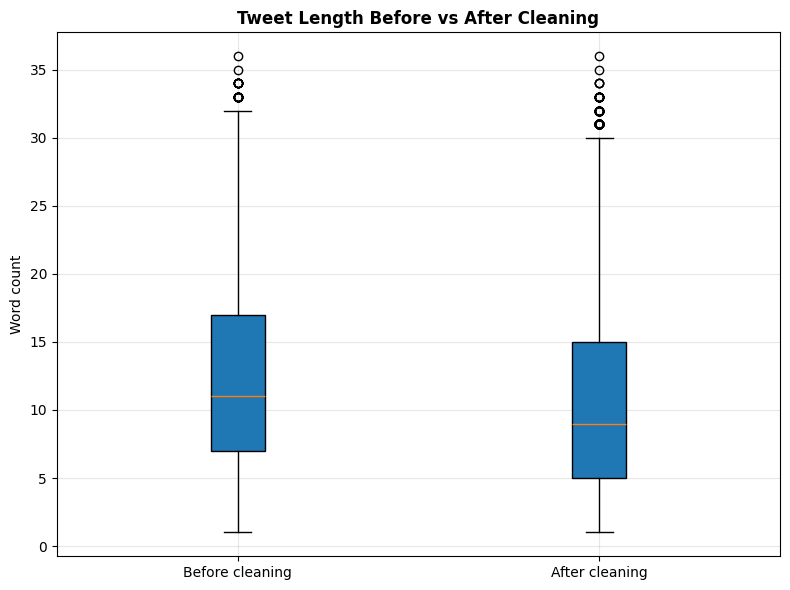

Average word count before cleaning: 12.13
Average word count after cleaning:  10.60
Average decrease in words:          1.53
Percent decrease after cleaning:    12.58%


In [7]:
df = pd.read_csv("outputs/tweets_emojis_clean.csv")
df = add_boxplot_columns(df)

plot_before_after_cleaning_boxplot(df)
print_cleaning_impact(df)

In [8]:
def plot_word_count_boxplot(df: pd.DataFrame) -> None:
    top_labels = df["label"].value_counts().head(10).index
    subset = df[df["label"].isin(top_labels)]

    plt.figure(figsize=(12, 6))
    subset.boxplot(column="word_count", by="label", rot=45)
    plt.title("Word Count by Emoji (Top 10)")
    plt.suptitle("")
    plt.xlabel("Emoji")
    plt.ylabel("Word Count")
    save_plot("06_word_count_boxplot.png")

In [9]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    counts = df["label"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(12, 7))
    counts.plot(kind="bar")
    plt.title("Emoji Class Distribution")
    plt.xlabel("Emoji Label")
    plt.ylabel("Number of Tweets")
    save_plot("01_class_distribution.png")

In [10]:
def plot_avg_word_count_by_label(df: pd.DataFrame) -> None:
    avg_words = df.groupby("label")["word_count"].mean().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    avg_words.plot(kind="bar")
    plt.title("Average Word Count by Emoji")
    plt.xlabel("Emoji Label")
    plt.ylabel("Average Words")
    save_plot("02_avg_word_count_by_label.png")

In [11]:
def plot_top_words(df: pd.DataFrame, top_n: int = 20) -> None:
    vectorizer = CountVectorizer(stop_words="english", min_df=20)
    X = vectorizer.fit_transform(df["clean_text"].fillna(""))
    words = pd.Series(X.sum(axis=0).A1, index=vectorizer.get_feature_names_out())
    top_idx = words.argsort()[-top_n:][::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(words.index[top_idx][::-1], words[top_idx][::-1])
    plt.title(f"Top {top_n} Words in Tweets")
    plt.xlabel("Count")
    plt.ylabel("Word")
    save_plot("04_top_words.png")

In [12]:
def plot_top_words(df: pd.DataFrame, top_n: int = 20) -> None:
    vectorizer = CountVectorizer(stop_words="english", min_df=20)
    X = vectorizer.fit_transform(df["clean_text"].fillna(""))
    words = pd.Series(X.sum(axis=0).A1, index=vectorizer.get_feature_names_out())
    top_idx = words.argsort()[-top_n:][::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(words.index[top_idx][::-1], words[top_idx][::-1])
    plt.title(f"Top {top_n} Words in Tweets")
    plt.xlabel("Count")
    plt.ylabel("Word")
    save_plot("04_top_words.png")

In [13]:
def plot_top_bigrams(df: pd.DataFrame, top_n: int = 15) -> None:
    vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=15)
    X = vectorizer.fit_transform(df["clean_text"].fillna(""))
    bigrams = pd.Series(X.sum(axis=0).A1, index=vectorizer.get_feature_names_out())
    top_idx = bigrams.argsort()[-top_n:][::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(bigrams.index[top_idx][::-1], bigrams[top_idx][::-1])
    plt.title(f"Top {top_n} Bigrams in Tweets")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    save_plot("05_top_bigrams.png")

In [14]:
def plot_top_hashtags(df: pd.DataFrame, top_n: int = 15) -> None:
    hashtag_text = " ".join(df["text"].fillna(""))
    hashtags = re.findall(r"#\w+", hashtag_text.lower())
    hashtag_counts = pd.Series(hashtags).value_counts().head(top_n)

    if hashtag_counts.empty:
        return

    plt.figure(figsize=(10, 5))
    hashtag_counts.sort_values().plot(kind="barh")
    plt.title("Top Hashtags")
    plt.xlabel("Count")
    plt.ylabel("Hashtag")
    save_plot("06_top_hashtags.png")


In [15]:
def plot_top_words_per_emoji(df: pd.DataFrame, top_n: int = 10, top_labels: int = 10) -> None:
    labels = df["label"].value_counts().head(top_labels).index.tolist()
    for label in labels:
        subset = df.loc[df["label"] == label, "clean_text"].fillna("")
        vectorizer = CountVectorizer(stop_words="english", min_df=10)
        X = vectorizer.fit_transform(subset)
        counts = np.asarray(X.sum(axis=0)).ravel()
        words = np.array(vectorizer.get_feature_names_out())
        top_idx = counts.argsort()[::-1][:top_n]
        plt.figure(figsize=(8, 4))
        plt.barh(words[top_idx][::-1], counts[top_idx][::-1])
        plt.title(f"Top Words for {label}")
        plt.xlabel("Count")
        plt.ylabel("Word")
        save_plot(f"top_words_{label}.png")

In [16]:
def plot_punctuation_usage(df: pd.DataFrame) -> None:
    cols = ["exclamation_count", "question_count"]
    means = df[cols].mean()

    plt.figure(figsize=(6, 4))
    means.plot(kind="bar")
    plt.title("Average Punctuation Usage")
    plt.ylabel("Average Count per Tweet")
    save_plot("07_punctuation_usage.png")

Loading cleaned data from: /datasets/_deepnote_work/outputs/tweets_emojis_clean.csv
Data shape: (225331, 11)
Columns: ['text', 'label', 'clean_text', 'char_count', 'word_count', 'has_link', 'has_mention', 'has_hashtag', 'is_retweet', 'exclamation_count', 'question_count']
                                                text       label  \
0  RT @VibingOverHoes: Bet you'll get hungry  htt...  heart_eyes   
1  Starbucks employee confuses boyfriend by sayin...         yum   
2  When your Starbucks store makes you an iced mo...         sob   

                                          clean_text  char_count  word_count  \
0                              bet you'll get hungry          66           4   
1  starbucks employee confuses boyfriend by sayin...          65          10   
2  when your starbucks store makes you an iced mo...          73          13   

   has_link  has_mention  has_hashtag  is_retweet  exclamation_count  \
0      True         True        False        True            

<Figure size 1200x600 with 0 Axes>

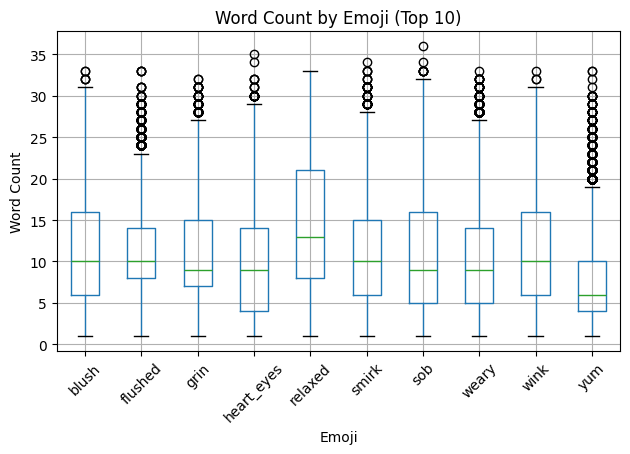

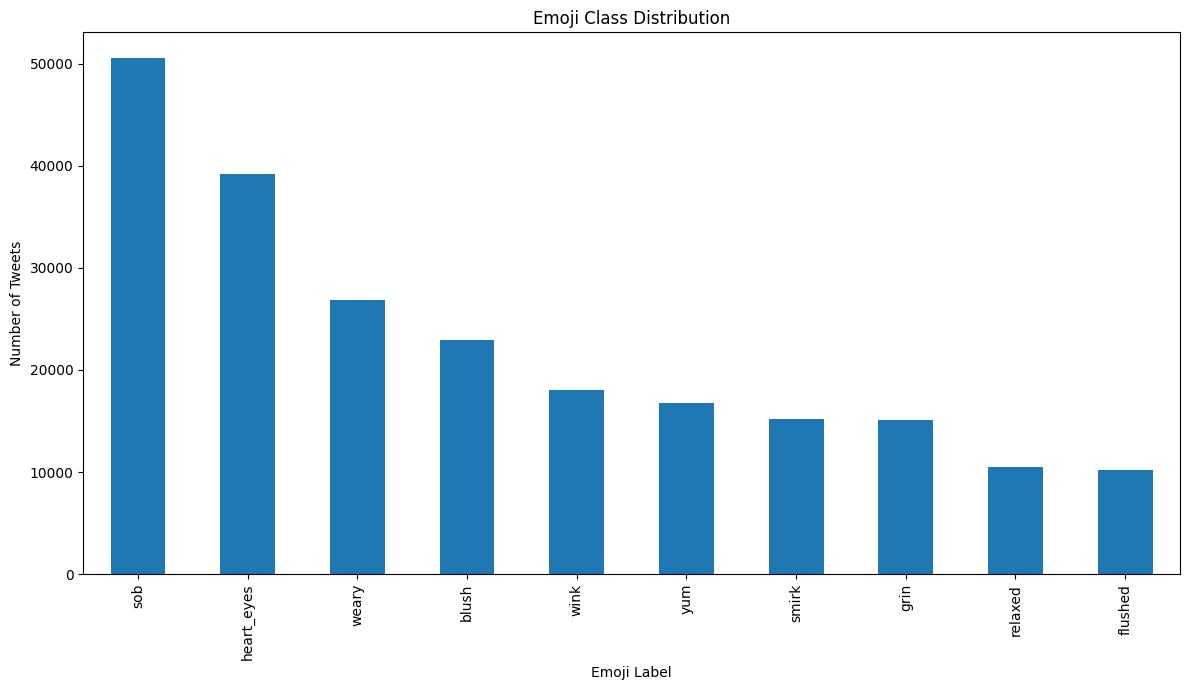

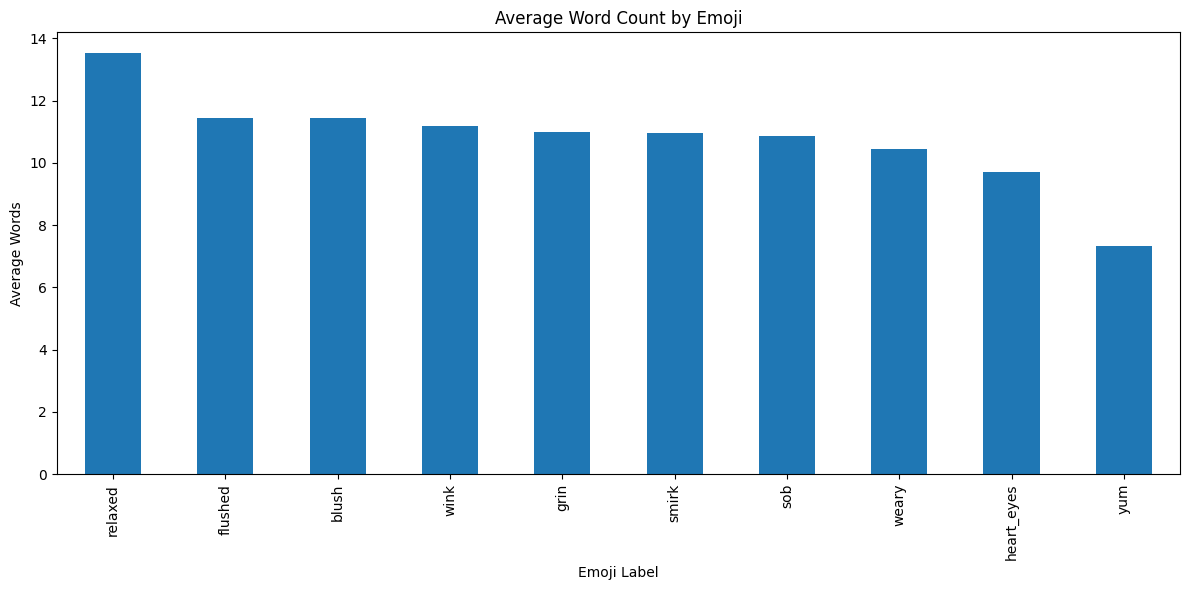

/tmp/ipykernel_5272/1779078806.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(words.index[top_idx][::-1], words[top_idx][::-1])


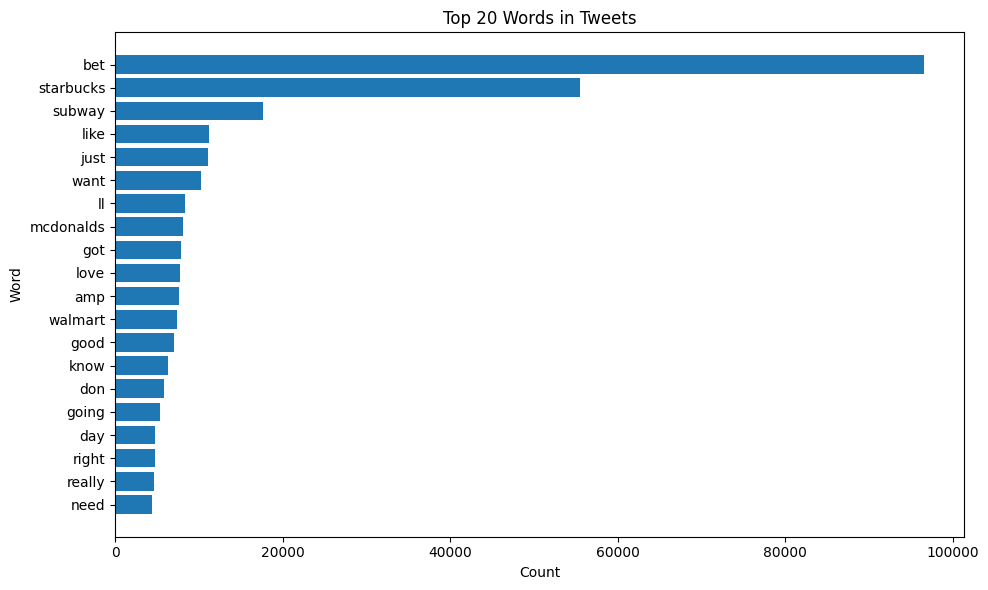

/tmp/ipykernel_5272/1706987757.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(bigrams.index[top_idx][::-1], bigrams[top_idx][::-1])


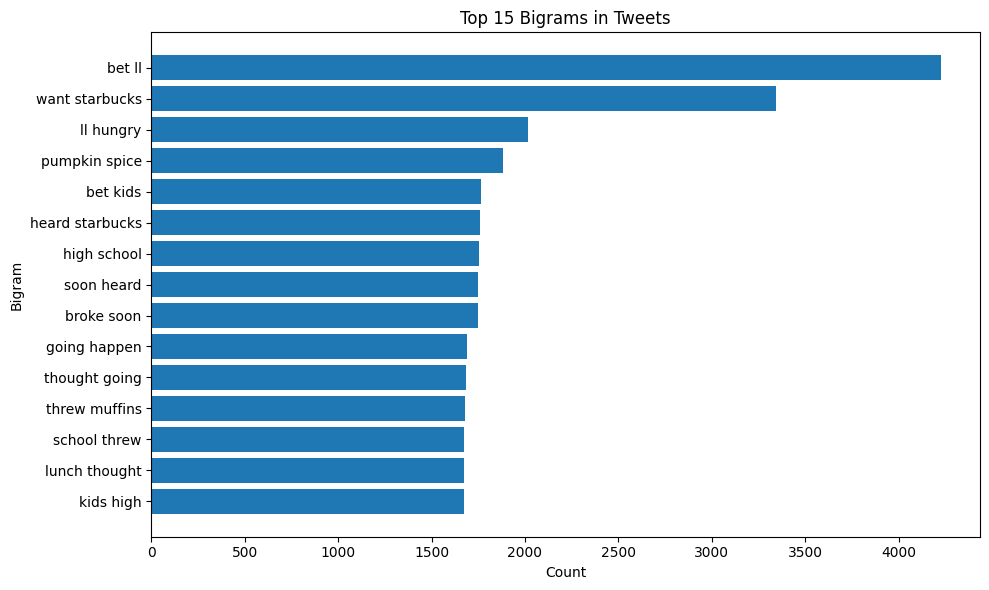

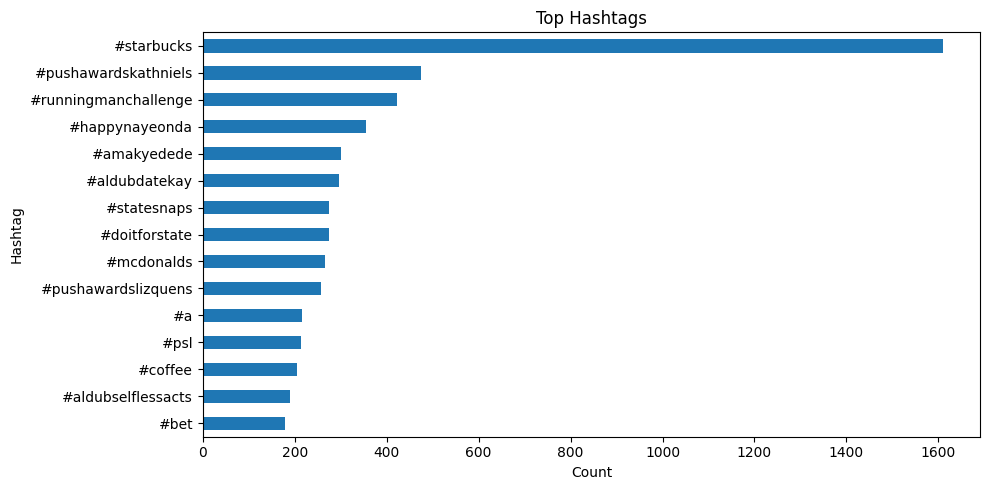

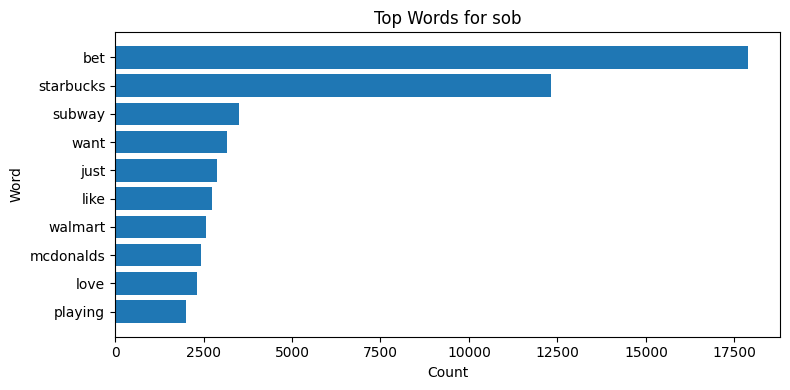

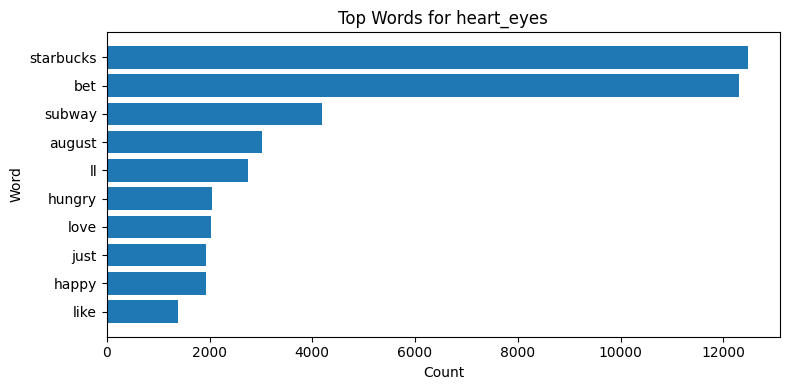

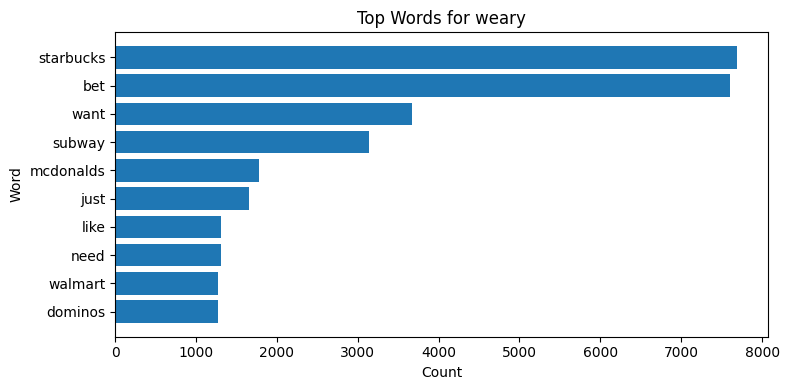

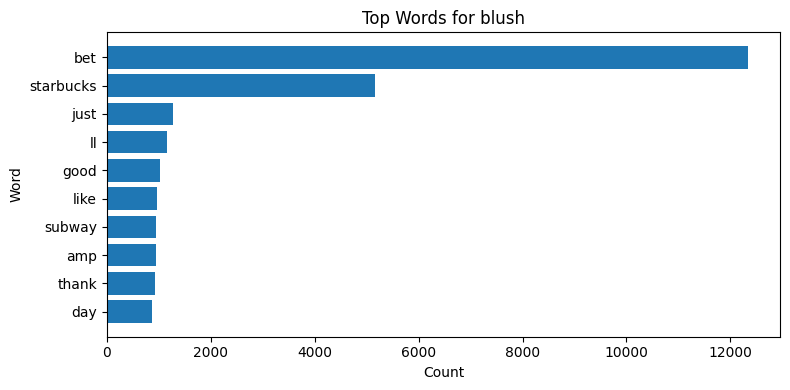

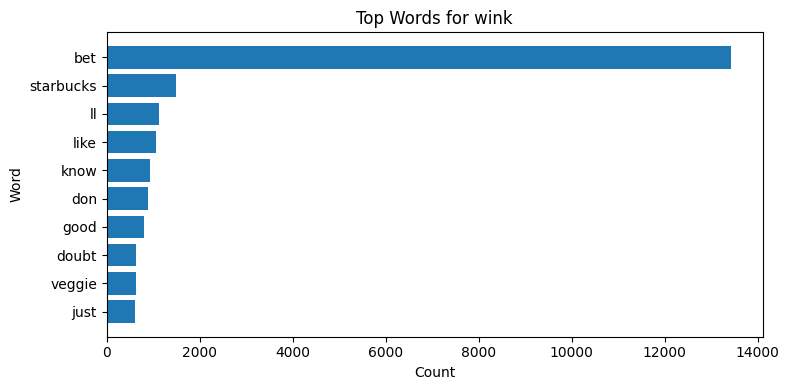

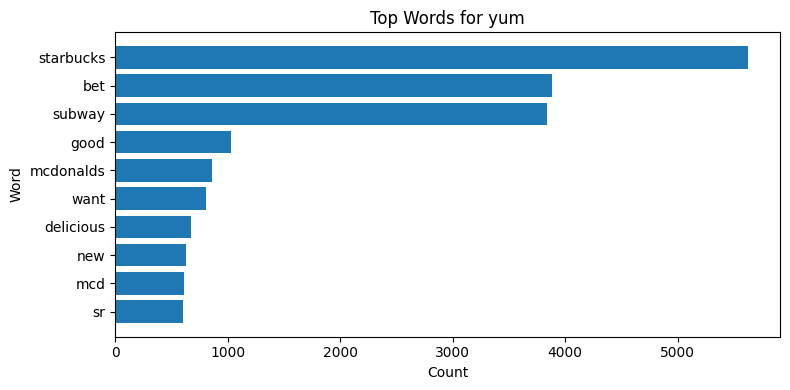

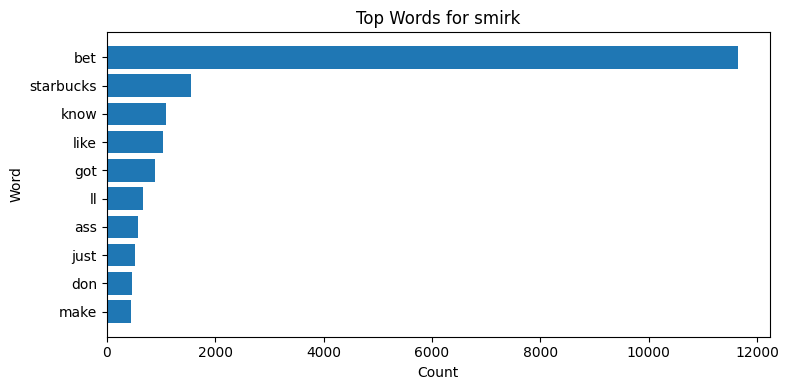

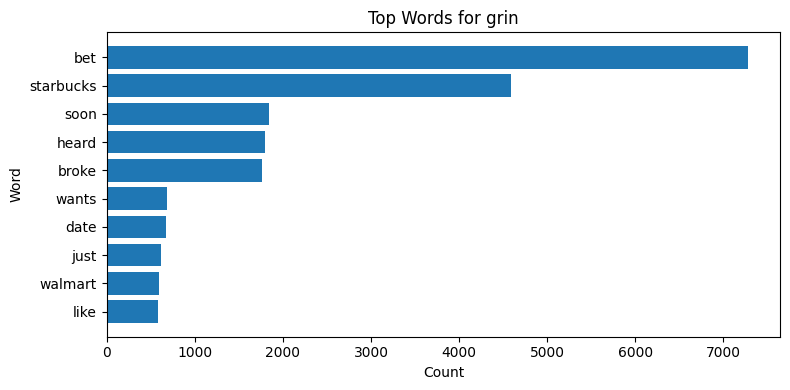

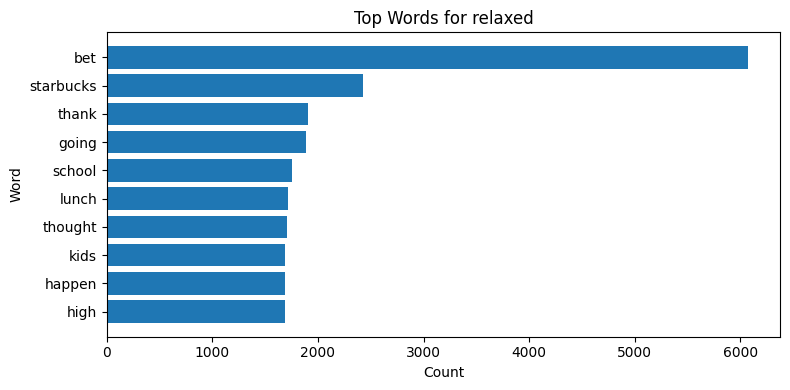

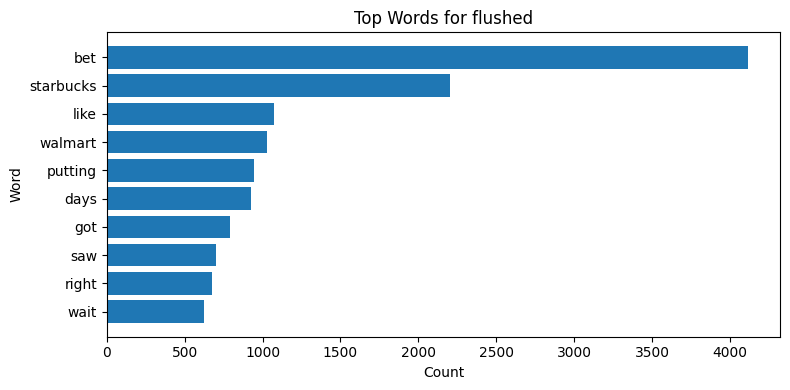

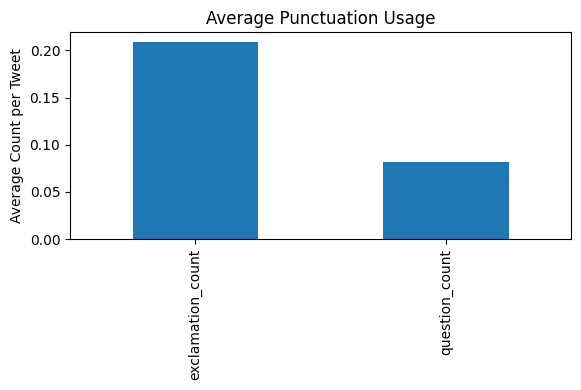

Saved figures to: /datasets/_deepnote_work/outputs/figures


In [17]:
def run_all_visualizations(df: pd.DataFrame | None = None) -> pd.DataFrame:
    if df is None:
        df = load_data()
    print("Data shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(3))
    plot_word_count_boxplot(df)
    plot_class_distribution(df)
    plot_avg_word_count_by_label(df)
    plot_top_words(df)
    plot_top_bigrams(df)
    plot_top_hashtags(df)
    plot_top_words_per_emoji(df)
    plot_punctuation_usage(df)
    print(f"Saved figures to: {FIG_DIR.resolve()}")
    return df
df = run_all_visualizations()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=62b91583-1382-466d-9446-3dc5e725c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>